# [개념 필사]
비지도 학습과 알고리즘 :군집, 이상치 탐지, 밀도 추정

## 9.1 군집
* 군집: 비슷해 보이는 꽃을 모으기 위해서

-> 비슷한 샘플을 구별해 하나의 클러스터

* 군집: 고객분류, 데이터분석, 차원축소기법, 이상치탐지, 준지도학습, 검색엔진, 이미지 분할

* 센트로이드 : 부르는 특정 포인트를 중심으로 모인 샘플을 찾음.

### 9.1.1 k-평균
* 반본 몇번으로 이런 종류의 데이터셋을 빠르고 효율적으로 클러스터로 묶을 수 있는 간단한 알고리즘.
*레이블: 알고르즘이 할당한 클러스터의 인덱스
*소프트군집: 하드 군집이라는 샘플을 하나의 클러스터에 할당하는 것보다 클러스터마다 샘플에 점수를 부여하는 것이 유용할 수 있음.
*trainsform() : 샘플과 각 센트로이드 사이의 거리 반환

**k_평균 알고리즘**
1) 센트로이드 랜덤하게 선정
2) 샘플에 레이블을 할당하고 센트로이드를 업데이트
3) 샘플에 레이블을 할당하고 센트로이드를 업데이트하여 센트로이드에 변화가 없을때까지 계속

**센트로이드 초기화 방법**
1) init 매개변수 : 센트로이드 리스트를 담을 넘파이 지정
2) 랜덤 초기화를 다르게 하여 여러번 알고리즘 실행하고 가장 좋은 솔루션을 선택하는 것
  * 이니셔: 각 샘플과 가장 가까운 센트로이드 사이의 평균 제곱 거리

**k-평균 속도 개선과 미니배치 k-평균**
* 전체 데이터셋 사용 반복 X-> 알고리즘마다 각 반복마다 미니배치를 사용해 센트로이드 조금씩 이동
* 일반 평균 알고리즘보다 속도가 빠름

**최적의 알고리즘 개수 찾기**
* 실제로 클러스터가 늘어날수록 각 샘플은 가까운 세트로이드에 가까워짐
-> 가장 작은 이니셔를 가진 모델 선택X

최선의 클러슽 개수 선택 방법
* 실루엣 점수
* 실루엣 계수 : (b-a)/max(a,b)
  * a: 동일한 클러스터에 있는 다른 샘플까지의 평균 거리
  * b: 가장 가까운 클러스터까지 평균 거리
* 실루엣 다이어그램 : 모든 샘플의 실루엣 계수를 할당된 클러슽와 계수값을 정렬하여 더 많은 정보 얻을 수 있음.

### 9.1.2 k-평균의 한계
* 알고리즘을 여러번 실행
* 클러스터 개수 지정
* 클러스터의 크기가 밀집도가 서로 다르거나 원형이 아닐 경우 작동 X

### 9.1.3 군집을 사용한 이미지 분할
* 이미지분할:이미지를 세그먼트 여러개로 분할하는 작업
* imread() 함수 사용

### 9.1.4 군집을 사용한 전처리
*k평균 전처리 단계: 먼저 훈련 세트를 모은 후 이미지를 클러스터까지의 거리로 바꿈-> 로지스틱 회귀적용

### 9.1.5 군집을 사용한 준지도 학슴
*준지도 학습: 레이블이 없는 데이터가 많고 레이블이 잇는 데이터는 적을때 사용함.
* 대표이미지: 각 클러스터에서 센트로이드에 가장 가까운 이미지를 찾음.
*레이블 전파: 동일한 클러스터에 있는 모든 샘플로 전파

### 9.1.6 DBSCAN
* 밀집된 연속된 지역을 클러스터로 정의함
* 핵심샘플: 밀집된 지역에 있는 샘플
-> 핵심X, 이웃X -> 이상치로 판단

### 9.1.7 다른 군집 알고르짐
* 병합군집: 클러스터 계층을 밑바다부터 위로 쌓아 구성
* BIRCH: 특벼히 대규모 데이터셋을 위해서 고안됨.
* 평균이동: 각 샘플을 중심으로 원 그림-> 원의 중심을 평균점으로 이동
* 유사도 전파: 투표 방식 사용
* 스펙트럼 군집: 샘ㅍ르 사이의 유사도 행렬을 받아 저차원  임베딩을 만듦.


---
# [코드 필사]




In [1]:
# 데이터 불러오기
from sklearn.datasets import make_blobs
import numpy as np

# make_blobs()의 정확한 인수는 중요하지 않습니다.
blob_centers = np.array([[ 0.2, 2.3], [-1.5 , 2.3], [-2.8, 1.8], [-2.8, 2.8], [-2.8, 1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std, random_state=7)

In [2]:
from sklearn.cluster import KMeans
k=5
kmeans=KMeans(n_clusters=k)
y_pred=kmeans.fit_predict(X)

In [3]:
y_pred

array([0, 0, 4, ..., 2, 1, 0], dtype=int32)

In [4]:
y_pred is kmeans.labels_

True

In [5]:
kmeans.cluster_centers_

array([[-2.80214068,  1.55162671],
       [ 0.05089714,  2.57710047],
       [-2.79290307,  2.79641063],
       [-1.47083264,  2.28276928],
       [ 0.33567783,  1.98622883]])

In [6]:
X_new=np.array([[0,2],[3,2],[-3,3], [-3,2.5]])
kmeans.predict(X_new)

array([4, 4, 2, 2], dtype=int32)

In [7]:
kmeans.transform(X_new)

array([[2.83778629, 0.57934055, 2.9042344 , 1.49776738, 0.33596019],
       [5.81943941, 3.00503788, 5.84739223, 4.47976595, 2.66435776],
       [1.4618254 , 3.08006775, 0.29040966, 1.68901531, 3.48632737],
       [0.96879317, 3.0518712 , 0.36159148, 1.54451999, 3.3750122 ]])

In [8]:
good_init=np.array([[-3,3],[-3,2],[-3,1],[-1,2],[0,2]])
kmeans=KMeans(n_clusters=5, init=good_init, n_init=1)

In [10]:
kmeans.fit_predict(X)
kmeans.inertia_

211.59853725816828

In [11]:
kmeans.score(X)

-211.59853725816828

In [12]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans=MiniBatchKMeans(n_clusters=5)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5)

In [13]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.655517642572828)

In [14]:
import matplotlib.pyplot as plt
from matplotlib.image import imread

image = plt.imread("/content/ladybug.png")
image.shape

(533, 800, 3)

In [15]:
X=image.reshape(-1,3)
kmeans=KMeans(n_clusters=8).fit(X)
segmented_img=kmeans.cluster_centers_[kmeans.labels_]
segmented_img=segmented_img.reshape(image.shape)

In [16]:
from sklearn.datasets import load_digits

X_digits, y_digits=load_digits(return_X_y=True)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_digits, y_digits)

In [18]:
from sklearn.linear_model import LogisticRegression

log_reg=LogisticRegression()
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [19]:
log_reg.score(X_test, y_test)

0.9666666666666667

In [20]:
from sklearn.pipeline import Pipeline

pipeline=Pipeline(
    [
        ('kmeans', KMeans(n_clusters=50)),
        ('log_reg', LogisticRegression())
    ]
)

pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                ('log_reg', LogisticRegression())])

In [21]:
pipeline.score(X_test, y_test)

0.9533333333333334

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid=dict(kmeans__n_clusters=range(2,100))
grid_clf=GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(X_train, y_train)

Fitting 3 folds for each of 98 candidates, totalling 294 fits
[CV] END ...............................kmeans__n_clusters=2; total time=   0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[CV] END ...............................kmeans__n_clusters=2; total time=   0.6s
[CV] END ...............................kmeans__n_clusters=2; total time=   0.2s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s
[CV] END ...............................kmeans__n_clusters=3; total time=   0.1s


...

[CV] END ..............................kmeans__n_clusters=99; total time=   1.7s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[CV] END ..............................kmeans__n_clusters=99; total time=   1.7s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('kmeans', KMeans(n_clusters=50)),
                                       ('log_reg', LogisticRegression())]),
             param_grid={'kmeans__n_clusters': range(2, 100)}, verbose=2)

In [23]:
grid_clf.best_params_

{'kmeans__n_clusters': 89}

In [24]:
grid_clf.score(X_test, y_test)

0.9533333333333334

In [25]:
n_labeled=50
log_reg=LogisticRegression()
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [26]:
log_reg.score(X_test, y_test)

0.8444444444444444

In [40]:
k = 50
kmeans = MiniBatchKMeans(n_clusters=k)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

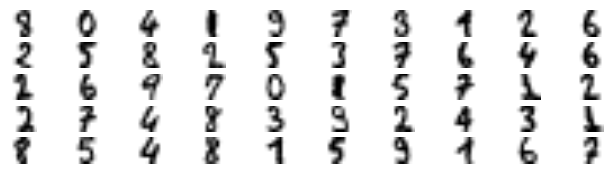

In [41]:
#추가 코드
plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')
plt.show()

In [50]:
y_representative_digits = np.array([8,0,4,1,9,7,3,1,2,6,2,5,8,2,5,3,7,6,4,6,2,6,9,7,0,8,5,7,1,2,2,7,4,8,3,3,2,4,3,1,8,5,4,8,1,5,9,1,6,7])

In [51]:
log_reg=LogisticRegression()
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.86

In [52]:
y_train_propagated=np.empty(len(X_train), dtype=np.int32)
for i in range(k):
  y_train_propagated[kmeans.labels_==i]=y_representative_digits[i]

In [53]:
log_reg=LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.86

In [54]:
percentile_closest = 20

X_cluster_dist = X_digits_dist[np.arange(len(X_train)),kmeans.labels_]
for i in range(k):
  in_cluster = (kmeans.labels_ == i)
  cluster_dist = X_cluster_dist[in_cluster]
  cutoff_distance = np.percentile(cluster_dist, percentile_closest)
  above_cutoff = (X_cluster_dist > cutoff_distance)
  X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [55]:
log_reg = LogisticRegression()
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.8511111111111112

In [56]:
y_train_propagated = np.empty(len(X_train), dtype=np.int32)
for i in range(k):
    y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

In [57]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.86

In [58]:
percentile_closest = 20

X_cluster_dist = X_digits_dist[np.arange(len(X_train)),kmeans.labels_]
for i in range(k):
  in_cluster = (kmeans.labels_ == i)
  cluster_dist = X_cluster_dist[in_cluster]
  cutoff_distance = np.percentile(cluster_dist, percentile_closest)
  above_cutoff = (X_cluster_dist > cutoff_distance)
  X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [59]:
log_reg = LogisticRegression()
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.8511111111111112

In [60]:
np.mean(y_train_partially_propagated == y_train[partially_propagated])

np.float64(0.9482758620689655)

In [61]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [62]:
dbscan.labels_

array([ 0,  1,  2,  3,  0,  2,  4,  5,  1, -1,  4,  0,  2,  4, -1,  2,  3,
        4,  0,  4,  3,  3,  0,  6,  0,  1,  0,  2,  4,  0,  2,  5,  6,  4,
        7,  4,  5,  6,  3,  6,  3,  3,  2,  2,  3,  0,  4,  3,  2,  6,  6,
        4,  3,  6,  7,  2, -1,  3,  1, -1,  2,  3,  2,  6,  8,  5,  1,  4,
        2,  1,  7,  3,  1,  4, -1,  3,  6,  1,  3,  4,  6,  1,  3,  3,  3,
        1,  5,  2,  6,  3,  6,  0,  3,  3,  4, -1,  0,  5,  0,  2,  4,  4,
        5,  4,  3,  2,  3,  3,  5,  1, -1,  4,  4,  7,  5,  3,  0,  3,  4,
        2,  5,  5,  4,  2,  2,  4,  4,  9,  3,  5,  3,  0,  0,  1,  0,  4,
        2,  6,  3,  3, -1,  6,  3,  5,  6,  1,  3,  6,  4,  6,  7,  0,  3,
        3,  4,  1,  7,  2,  3,  3,  2,  4,  8, -1,  2,  1,  0,  3,  7,  5,
        7,  0,  3,  3,  1,  4,  2,  3,  3,  3,  4,  0,  7,  5,  7,  5,  4,
        2,  1,  0,  3,  1,  4,  7,  4, -1, -1,  4,  3,  5,  0, -1,  1,  6,
        3,  4,  2,  4,  6,  3,  3, -1,  2,  1,  0,  0,  1,  7,  4,  0,  3,
        4,  4,  1,  3, -1

In [63]:
len(dbscan.core_sample_indices_)

810

In [64]:
dbscan.core_sample_indices_

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,  10,  11,  12,  13,
        15,  16,  17,  18,  19,  21,  22,  23,  24,  25,  26,  27,  28,
        29,  30,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
        57,  58,  60,  62,  63,  66,  67,  68,  69,  70,  71,  72,  73,
        75,  76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,
        88,  89,  90,  91,  92,  94,  96,  97,  98,  99, 100, 101, 102,
       104, 105, 106, 107, 109, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 128, 129, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 141, 142, 143, 144, 145, 146, 147,
       148, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161,
       164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 175, 176, 177,
       178, 179, 180, 181, 183, 184, 187, 188, 189, 190, 191, 193, 194,
       197, 198, 199, 200, 204, 205, 206, 207, 210, 212, 214, 21

In [65]:
dbscan.components_

array([[-0.8062203 ,  0.55736708],
       [ 0.18733884,  0.97824585],
       [ 0.94122519,  0.3467779 ],
       ...,
       [ 0.07889549,  0.20462528],
       [ 1.93822833,  0.3192691 ],
       [ 0.57931688, -0.37866924]])

In [66]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [67]:
X_new = np.array([[-0.5,0],[0,0.5],[1,-0.1],[2,1]])
knn.predict(X_new)

array([7, 3, 2, 4])

In [68]:
knn.predict_proba(X_new)

array([[0.06, 0.  , 0.  , 0.16, 0.  , 0.  , 0.  , 0.78, 0.  , 0.  ],
       [0.  , 0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.74, 0.12, 0.  , 0.14, 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.  , 0.  , 0.98, 0.  , 0.  , 0.  , 0.  , 0.02]])

In [69]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist >0.2] = -1
y_pred.ravel()

array([-1,  3,  2, -1])